<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/My_Live_Handson/AI(Deep_Learning)/CNN_Handson_by_me.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Very Good Morning Everyone! 🌞

I hope you're all feeling energized and ready to learn today 😄
It’s great to see everyone joining in!

🧠 What’s on our plate today?

We’ll be diving into a hands-on practice session on Convolutional Neural Networks (CNNs).
Get ready — it's going to be fun, practical, and insightful! 🚀

⏳ We’ll start shortly, so please stay connected and wait for a few more minutes.

# 🧪 CNN Hands-On: CIFAR-10 Image Classification

In this exercise, you will work with the **CIFAR-10 dataset**, a popular benchmark dataset used in computer vision.

---

## 📦 About the Dataset

- Contains **60,000 color images**
- Each image size: **32×32 pixels**
- **10 categories**:

`Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck`

- Split into:
  - **50,000 training images**
  - **10,000 testing images**

---

## 🎯 Your Task

Build a **Convolutional Neural Network (CNN)** that can classify images into one of the **10 classes**.

You will:

1. Load the CIFAR-10 dataset  
2. Normalize the images  
3. Build a simple CNN  
4. Train and evaluate the model  
5. Test predictions on sample images  

---

👉 Keep the model simple — the goal is to **understand how CNNs work**, not achieve the highest accuracy.

Good luck! 🚀


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np

# 1. Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks
from tensorflow import keras

In [3]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.2 MB/s eta 0:00:00


In [4]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
import keras_tuner as kt
import pickle
import os

In [5]:
x_train.shape

(50000, 32, 32, 3)

In [6]:
x_test.shape

(10000, 32, 32, 3)

In [7]:
y_train.shape

(50000, 1)

In [8]:
y_train[1]

array([9], dtype=uint8)

In [9]:
np.max(y_train)

np.uint8(9)

In [10]:
np.max(x_train)

np.uint8(255)

In [11]:
np.max(x_test)

np.uint8(255)

In [12]:
5/2

2.5

NORMALIZING

In [13]:
x_train = x_train / 255

In [14]:
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [15]:
np.max(x_train)

np.float64(1.0)

In [16]:
x_test = x_test / 255

In [17]:
np.max(x_test)

np.float64(1.0)

In [18]:
x_train.shape

(50000, 32, 32, 3)

In [19]:
x_train[0].shape

(32, 32, 3)

Building a simple CNN

In [20]:
from tensorflow.keras.layers import LeakyReLU

In [21]:
#define Cnn
def create_model():
  model = models.Sequential([
      layers.Conv2D(64, (9,9), activation='leaky_relu',
                    input_shape=(x_train[0].shape)),
      layers.BatchNormalization(),
      layers.MaxPooling2D((4,4)),

      layers.Conv2D(128, (3,3), activation='leaky_relu'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2,2)),

      layers.Conv2D(128, (3,3), padding='same' ,activation='relu'),
      layers.BatchNormalization(),

      layers.Flatten(),

      #ANN
      layers.Dense(128,activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(10, activation='softmax')
  ])
  return model

In [22]:
early_stopping = callbacks.EarlyStopping(patience=5,
                                         restore_best_weights=True)

In [23]:
cifar_model = create_model()
cifar_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,290 (1.16 MB)

 Trainable params: 304,650 (1.16 MB)

 Non-trainable params: 640 (2.50 KB)

In [24]:
cifar_model.compile(optimizer="adam", loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [25]:
history = cifar_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    validation_split=0.20,
    verbose=2,
)

Epoch 1/15
1250/1250 - 14s - 11ms/step - accuracy: 0.3874 - loss: 1.7023 - val_accuracy: 0.4463 - val_loss: 1.4994
Epoch 2/15
1250/1250 - 6s - 5ms/step - accuracy: 0.5102 - loss: 1.3738 - val_accuracy: 0.2705 - val_loss: 2.6942
Epoch 3/15
1250/1250 - 5s - 4ms/step - accuracy: 0.5765 - loss: 1.2198 - val_accuracy: 0.5203 - val_loss: 1.3917
Epoch 4/15
1250/1250 - 5s - 4ms/step - accuracy: 0.6196 - loss: 1.0896 - val_accuracy: 0.5252 - val_loss: 1.3484
Epoch 5/15
1250/1250 - 5s - 4ms/step - accuracy: 0.6531 - loss: 0.9956 - val_accuracy: 0.6317 - val_loss: 1.0610
Epoch 6/15
1250/1250 - 5s - 4ms/step - accuracy: 0.6811 - loss: 0.9171 - val_accuracy: 0.5679 - val_loss: 1.5204
Epoch 7/15
1250/1250 - 10s - 8ms/step - accuracy: 0.7049 - loss: 0.8470 - val_accuracy: 0.6049 - val_loss: 1.2412
Epoch 8/15
1250/1250 - 6s - 5ms/step - accuracy: 0.7242 - loss: 0.7938 - val_accuracy: 0.6466 - val_loss: 1.0865
Epoch 9/15
1250/1250 - 5s - 4ms/step - accuracy: 0.7479 - loss: 0.7337 - val_accuracy: 0.6556

In [56]:
cifar_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 914,592 (3.49 MB)

 Trainable params: 304,650 (1.16 MB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 609,302 (2.32 MB)

In [26]:
np.floor((32 - 9) / 1) +1

np.float64(24.0)

In [27]:
np.floor((24 - 4) / 4) + 1

np.float64(6.0)

In [28]:
np.floor((6 - 3) / 1) +1

np.float64(4.0)

In [29]:
np.floor((4 - 2) / 2) +1

np.float64(2.0)

In [30]:
np.floor((2 - 3) / 1) + 1

np.float64(0.0)

When padding='same',

For any Conv2D layer:

output_height = ceil(input_height / stride)

output_width  = ceil(input_width / stride)

In [31]:
# last layer we get error as kernel size more than input size of 2. so we do padding to input before using kernel

# last layer. we gvet input 2x2x128 - 128 channels
# output also will be 2x2

# O = floor((I + 2P - F) / S) + 1
# p = k-1 / 2

P = (3-1) / 2

In [32]:
P

1.0

In [33]:
O = np.floor((2 + 2*1 - 3) / 1) + 1

In [34]:
O

np.float64(2.0)

Text(0, 0.5, 'Loss')

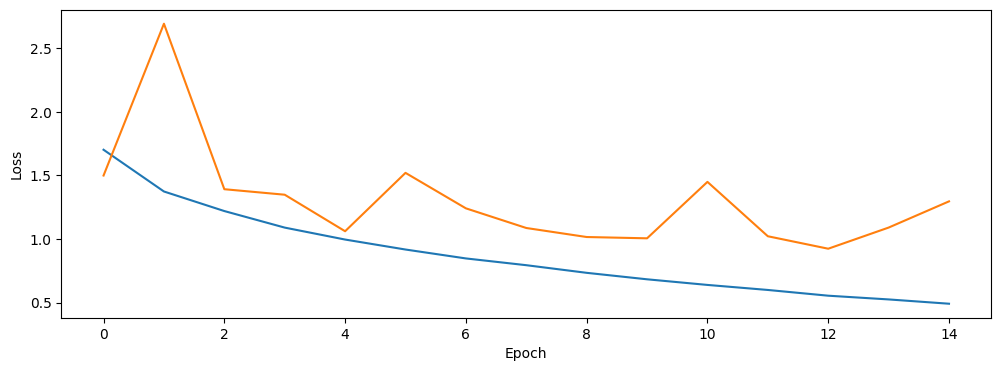

In [35]:
plt.figure(figsize=(12,4))
plt.plot(history.history['loss'], label='Training Accuracy')
plt.plot(history.history['val_loss'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [36]:
test_loss, test_accuracy = cifar_model.evaluate(x_test, y_test)
print("test loss:", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7045 - loss: 0.9546
test loss: 0.9667125940322876


NameError: name 'tes_accuracy' is not defined

In [37]:
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7020000219345093


In [38]:
predictions = cifar_model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [39]:
predictions

array([[4.51293090e-05, 3.63131840e-05, 2.76271580e-03, ...,
        7.32033513e-05, 1.11148756e-06, 3.25026758e-06],
       [4.11822870e-02, 5.96250117e-01, 3.48838398e-06, ...,
        1.04395394e-05, 3.61106515e-01, 1.35234906e-03],
       [2.06069157e-01, 2.22359076e-02, 5.01840259e-04, ...,
        1.11392343e-04, 7.52290785e-01, 1.77030116e-02],
       ...,
       [1.03854057e-10, 4.02021694e-10, 2.40944973e-05, ...,
        1.05847721e-05, 1.10254215e-08, 8.23547674e-10],
       [3.45601350e-01, 1.36100799e-01, 2.06556842e-02, ...,
        1.88177880e-02, 3.30747245e-03, 1.81687938e-03],
       [1.25553488e-08, 4.44731925e-12, 3.06278309e-07, ...,
        9.99307871e-01, 1.30155730e-11, 2.47098786e-10]], dtype=float32)

In [42]:
predictions.shape

(10000, 10)

In [43]:
y_pred = np.argmax(predictions, axis=1)

In [44]:
y_pred

array([3, 1, 8, ..., 5, 0, 7])

In [45]:
y_pred.shape

(10000,)

In [46]:
accuracy_score(y_test, y_pred)

0.702

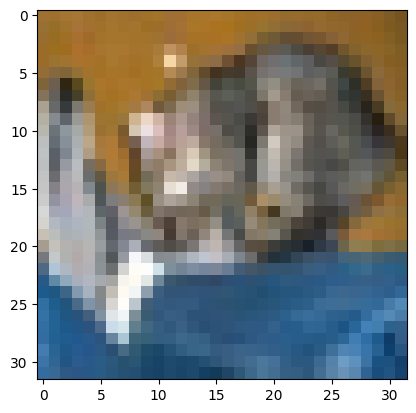

In [47]:
plt.imshow(x_test[0])

In [48]:
y_test[0]

array([3], dtype=uint8)

In [49]:
y_pred[0]

np.int64(3)

In [71]:
def create_model_2():
  model = models.Sequential([
      tf.keras.layers.InputLayer(batch_input_shape=(32, 32, 32, 3)),
      layers.Conv2D(64, (9,9), activation='leaky_relu'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((4,4)),

      layers.Conv2D(128, (3,3),activation='relu'),
      layers.BatchNormalization(),

      layers.Flatten(),

      #ANN
      layers.Dense(128,activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model

In [72]:
cifar_model_2 = create_model_2()
cifar_model_2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (32, 24, 24, 64)       │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (32, 24, 24, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (32, 4, 4, 128)        │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (32, 4, 4, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (32, 2048)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (32, 128)              │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (32, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,802 (1.35 MB)

 Trainable params: 353,418 (1.35 MB)

 Non-trainable params: 384 (1.50 KB)

In [58]:
labels = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

In [75]:
indices = np.where(y_test == 7)


In [78]:
len(indices)

2

In [79]:
indices[0]

array([  13,   17,   20,   48,   56,   57,   60,   69,   83,   87,   99,
        109,  119,  137,  145,  177,  194,  198,  203,  208,  210,  216,
        220,  228,  263,  268,  288,  316,  317,  326,  339,  355,  371,
        375,  377,  386,  402,  410,  417,  419,  433,  435,  445,  452,
        468,  471,  475,  506,  521,  523,  541,  543,  561,  567,  571,
        578,  596,  620,  621,  624,  634,  643,  662,  693,  698,  700,
        704,  713,  732,  741,  743,  745,  766,  782,  784,  794,  795,
        798,  800,  803,  808,  809,  812,  824,  826,  840,  842,  850,
        855,  856,  858,  867,  879,  892,  897,  905,  934,  942,  955,
        958,  974,  984, 1037, 1040, 1057, 1073, 1096, 1100, 1107, 1119,
       1130, 1149, 1157, 1162, 1169, 1170, 1198, 1201, 1209, 1215, 1224,
       1236, 1246, 1250, 1296, 1299, 1320, 1333, 1342, 1351, 1360, 1379,
       1391, 1398, 1402, 1415, 1426, 1428, 1433, 1466, 1469, 1470, 1472,
       1473, 1476, 1477, 1478, 1486, 1494, 1520, 15

In [80]:
indices[0][0]

np.int64(13)

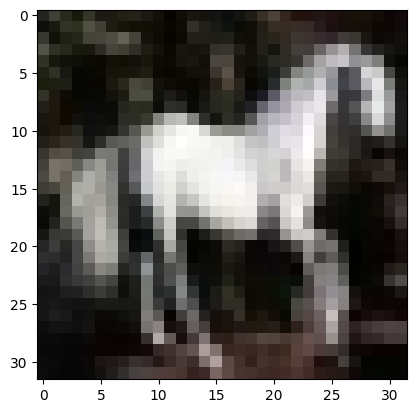

In [81]:
plt.imshow(x_test[indices[0][0]])

In [82]:
labels[7]

'Horse'

In [91]:
x_test[13:14].shape

(1, 32, 32, 3)

In [93]:
np.array([x_test[13]])

array([[[[0.1372549 , 0.14117647, 0.12156863],
         [0.24705882, 0.25098039, 0.21568627],
         [0.15294118, 0.16078431, 0.11372549],
         ...,
         [0.0745098 , 0.04313725, 0.03137255],
         [0.05098039, 0.01960784, 0.01960784],
         [0.07058824, 0.03137255, 0.03529412]],

        [[0.05098039, 0.05490196, 0.03529412],
         [0.09411765, 0.10196078, 0.0627451 ],
         [0.19215686, 0.2       , 0.15294118],
         ...,
         [0.05098039, 0.02745098, 0.01568627],
         [0.04705882, 0.02352941, 0.01960784],
         [0.06666667, 0.03921569, 0.03921569]],

        [[0.21568627, 0.22352941, 0.18823529],
         [0.0627451 , 0.07058824, 0.03137255],
         [0.11764706, 0.1254902 , 0.08235294],
         ...,
         [0.04705882, 0.03137255, 0.01960784],
         [0.05882353, 0.04313725, 0.03137255],
         [0.0745098 , 0.05882353, 0.05098039]],

        ...,

        [[0.03137255, 0.03137255, 0.03137255],
         [0.03137255, 0.03137255, 0.03137255]

In [94]:
np.array([x_test[13]]).shape

(1, 32, 32, 3)

In [98]:
cifar_model.predict(np.array([x_test[13]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[7.7769846e-06, 2.0348882e-08, 1.0240853e-03, 4.2097237e-02,
        6.6125435e-03, 2.1996999e-01, 6.7481233e-05, 7.3021978e-01,
        1.1308067e-07, 9.7918860e-07]], dtype=float32)

In [99]:
np.argmax(cifar_model.predict(np.array([x_test[indices[0][0]]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


np.int64(7)

In [101]:
labels[np.argmax(cifar_model.predict(np.array([x_test[indices[0][0]]])))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


'Horse'

Testing with an image from internet

In [102]:
image_url = "https://images.rawpixel.com/image_800/czNmcy1wcml2YXRlL3Jhd3BpeGVsX2ltYWdlcy93ZWJzaXRlX2NvbnRlbnQvZnJob3JzZV9nYWxsb3BfY2FudGVyX21hcmUtaW1hZ2Utcm01MDNfMS1sMDd0dW5iZy5qcGc.jpg"

In [116]:
from PIL import Image
import requests
from io import BytesIO

response = requests.get(image_url)
img = Image.open(BytesIO(response.content))


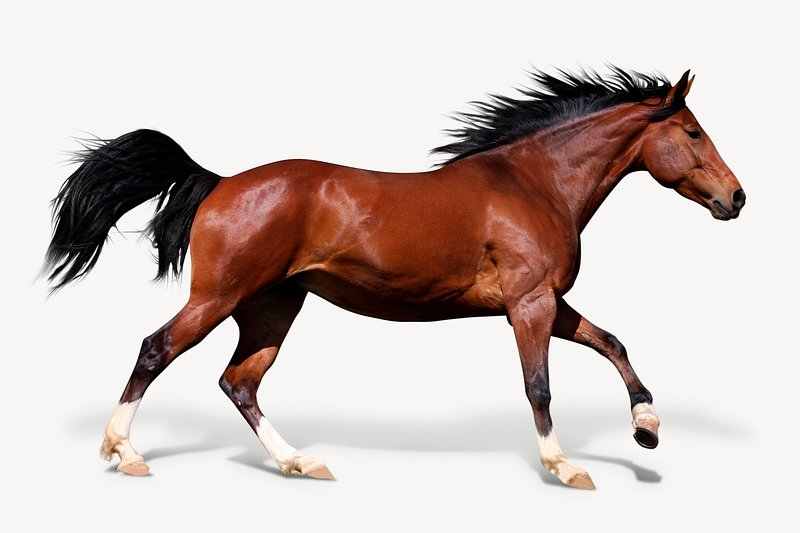

In [117]:
img

array([[[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       ...,

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]]], dtype=uint8)
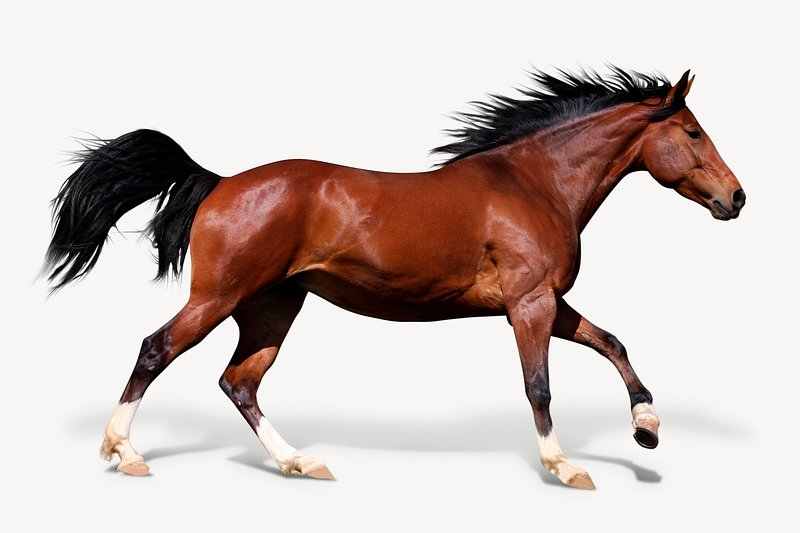

In [118]:
np.array(img)

In [111]:
img = img.convert("RGB")

array([[[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       ...,

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]],

       [[247, 246, 244],
        [247, 246, 244],
        [247, 246, 244],
        ...,
        [247, 246, 244],
        [247, 246, 244],
        [247, 246, 244]]], dtype=uint8)
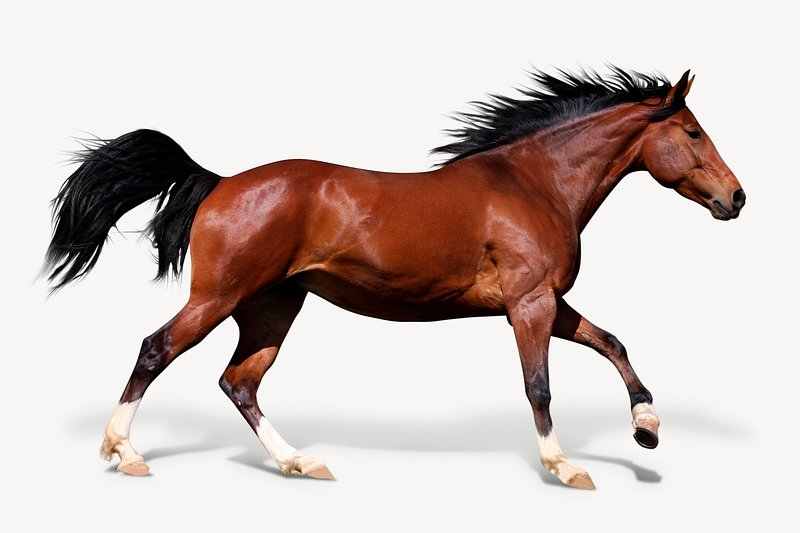

In [107]:
np.array(img)

In [112]:
img = img.resize((32, 32))

In [113]:
np.array(img).shape

(32, 32, 3)

In [114]:
labels[np.argmax(cifar_model.predict(np.array([np.array(img)])))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


'Horse'

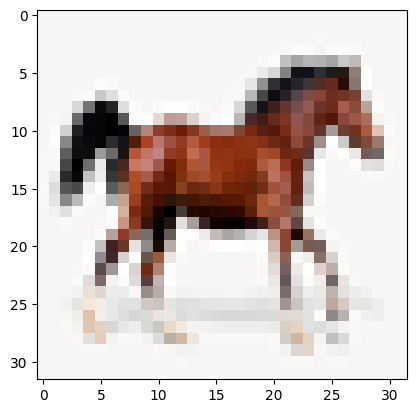

In [115]:
plt.imshow(img)